In [3]:
import numpy as np
import torch
import os
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

In [4]:
# Load the data from the specified directory
X_train = np.load('../ProcessedInputData/X_train_seq.npy')
Y_train = np.load('../ProcessedInputData/y_train_seq.npy')
X_val = np.load('../ProcessedInputData/X_val_seq.npy')
Y_val = np.load('../ProcessedInputData/y_val_seq.npy')


# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
Y_val_tensor = torch.tensor(Y_val, dtype=torch.long)

# Create a DataLoader for batching
batch_size = 64
train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False) # don't shuffle for LTSM?
val_dataset = TensorDataset(X_val_tensor, Y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

sanity_dataset = TensorDataset(X_train_tensor[:20], Y_train_tensor[:20]) # take just a few elements
sanity_loader = DataLoader(sanity_dataset, batch_size=5, shuffle=False)

In [5]:
# Print the first few elements of the tensors
print("First few elements of Y_train_tensor:")
print(Y_train_tensor.size())
print(Y_train_tensor[:30])  # Print first 10 elements

print("First few elements of X_train_tensor:")
print(X_train_tensor.size())
# print(X_train_tensor[:3])  # Print first 3 elements

# each input is 5x90x1 matrix
# 5 bc there are 5 eeg channels recordings per sample,
# 90 bc i did fourier transform and binned it into 90 different bins from 0.5 to 40 Hz (relevant frequencies for EEG)
# the 1 was added just to be the dimension of picture style for CNN so its like black and white

# Update: now 90x1 where each channel is separate datapoint

print("Val tensors:")
print(Y_val_tensor.size())
print(X_val_tensor.size())

# original size [3153, 5, 90, 1]
# current size  [15768, 90, 1]

First few elements of Y_train_tensor:
torch.Size([1598])
tensor([0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0,
        1, 0, 0, 1, 0, 1])
First few elements of X_train_tensor:
torch.Size([1598, 5, 90, 1])
Val tensors:
torch.Size([200])
torch.Size([200, 5, 90, 1])


In [ ]:
# Conv2d expecs (batch size, channels, height, width) 4D input

Epoch [1/200]
Train Loss: 31.6745 | Train Accuracy: 51.25%
Val Loss: 8.3062 | Val Accuracy: 50.50%

Epoch [2/200]
Train Loss: 7.9148 | Train Accuracy: 52.57%
Val Loss: 21.6532 | Val Accuracy: 52.00%

Epoch [3/200]
Train Loss: 13.1306 | Train Accuracy: 53.50%
Val Loss: 53.8845 | Val Accuracy: 50.50%

Epoch [4/200]
Train Loss: 37.1444 | Train Accuracy: 50.75%
Val Loss: 53.5310 | Val Accuracy: 52.00%

Epoch [5/200]
Train Loss: 53.9505 | Train Accuracy: 51.06%
Val Loss: 20.7080 | Val Accuracy: 53.50%

Epoch [6/200]
Train Loss: 9.8457 | Train Accuracy: 50.69%
Val Loss: 74.6371 | Val Accuracy: 50.50%

Epoch [7/200]
Train Loss: 6.6521 | Train Accuracy: 51.25%
Val Loss: 16.1639 | Val Accuracy: 49.50%

Epoch [8/200]
Train Loss: 3.2466 | Train Accuracy: 51.81%
Val Loss: 45.8298 | Val Accuracy: 51.50%

Epoch [9/200]
Train Loss: 2.5403 | Train Accuracy: 52.63%
Val Loss: 38.8592 | Val Accuracy: 51.50%

Epoch [10/200]
Train Loss: 2.4355 | Train Accuracy: 55.13%
Val Loss: 25.8471 | Val Accuracy: 52.5

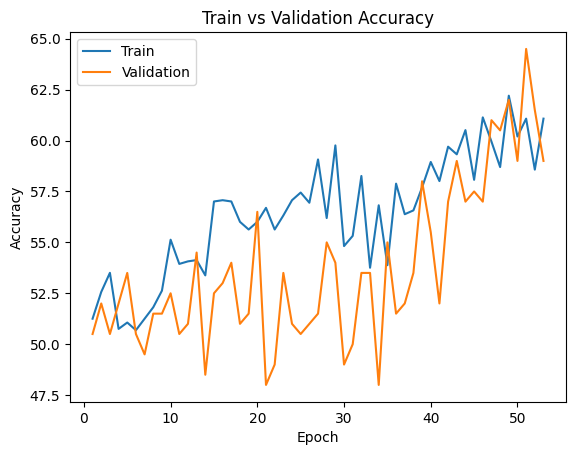

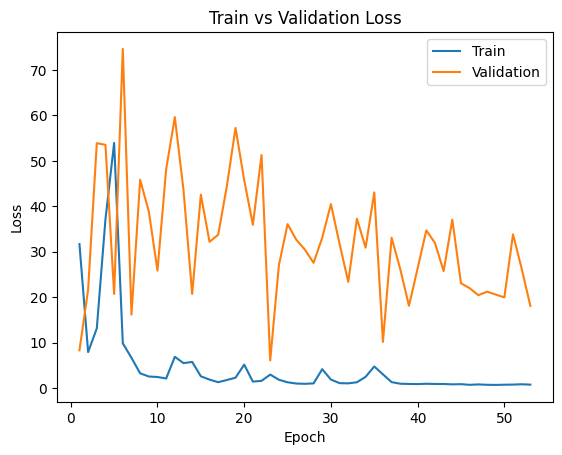

In [11]:
def train_and_validate(model, train_loader, val_loader, epochs=100, patience=20, print_every=5):
    torch.manual_seed(1000)
    model.train()
    criterion = nn.BCEWithLogitsLoss()  
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    best_val_loss = float("inf")  # Initialize best validation loss
    best_val_acc = 0
    patience_counter = 0  # Counts epochs without improvement
    best_model_state = None  # Store best model weights

    train_accuracies = []
    val_accuracies = []
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        # Training loop
        model.train()
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            labels = labels.view(-1, 1).float()
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            predicted = torch.round(torch.sigmoid(outputs))  
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        avg_train_loss = running_loss / len(train_loader)
        train_accuracy = 100 * correct / total

        # Validation loop (no gradient updates)
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                outputs = model(inputs)
                labels = labels.view(-1, 1).float()
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                predicted = torch.round(torch.sigmoid(outputs))
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        avg_val_loss = val_loss / len(val_loader)
        val_accuracy = 100 * val_correct / val_total

        # Print results
        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f"Train Loss: {avg_train_loss:.4f} | Train Accuracy: {train_accuracy:.2f}%")
        print(f"Val Loss: {avg_val_loss:.4f} | Val Accuracy: {val_accuracy:.2f}%\n")

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)

        # Early Stopping Logic
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss  # Update best loss
            patience_counter = 0  # Reset counter
            best_model_state = model.state_dict()  # Save best model
        else:
            patience_counter += 1  # Increment counter

        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs!")
            break  # Stop training

        if val_accuracy > best_val_acc:
            best_val_acc = val_accuracy

    # Load best model before exiting
    if best_model_state:
        model.load_state_dict(best_model_state)
        print("Loaded best model with lowest validation loss.")

    print(f"Best val accuracy: {best_val_acc}")
    print(f"Best val loss: {best_val_loss}")

    # Plot the curves
    import matplotlib.pyplot as plt
    plt.title("Train vs Validation Accuracy")
    n = len(train_accuracies) # number of epochs
    plt.plot(range(1,n+1), train_accuracies, label="Train")
    plt.plot(range(1,n+1), val_accuracies, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend(loc='best')
    plt.show()
    plt.title("Train vs Validation Loss")
    plt.plot(range(1,n+1), train_losses, label="Train")
    plt.plot(range(1,n+1), val_losses, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(loc='best')
    plt.show()

    return model  # Return best model

# Xavier Initialization Function
def init_weights(m):
    if isinstance(m, nn.Linear) or isinstance(m, nn.Conv1d):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

# My model
import torch
import torch.nn as nn

class AntoineNet(nn.Module):
    def __init__(self):
        super(AntoineNet, self).__init__()

        # CNN Layers
        self.conv1 = nn.Conv2d(1, 16, kernel_size=(3, 3), padding=1)  
        self.conv2 = nn.Conv2d(16, 32, kernel_size=(3, 3), padding=1)
        self.pool = nn.MaxPool2d(kernel_size=(2, 2), stride=2)  
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.1)  

        # Compute CNN output size dynamically
        self._to_linear = None
        self._compute_linear_input_size()

        # Fully Connected Layers
        self.fc0 = nn.Linear(self._to_linear, 64)  # First FC layer
        self.fc1 = nn.Linear(64, 1)  # Output layer

    def _compute_linear_input_size(self):
        with torch.no_grad():
            x = torch.zeros(1, 1, 5, 90)  # Dummy input
            x = self.pool(self.relu(self.conv1(x)))  
            x = self.dropout(x)
            x = self.pool(self.relu(self.conv2(x)))  
            x = self.dropout(x)
            x = x.view(x.size(0), -1)  # Fully flatten
            self._to_linear = x.shape[1]  # Extract feature size

    def forward(self, x):
        x = x.view(-1, 1, 5, 90)  # Ensure correct shape
        x = self.pool(self.relu(self.conv1(x)))  
        x = self.dropout(x)
        x = self.pool(self.relu(self.conv2(x)))  
        x = self.dropout(x)

        # Flatten for FC layers
        x = x.view(x.size(0), -1)  

        # Fully Connected Layers
        x = self.relu(self.fc0(x))  # First FC layer with activation
        x = self.fc1(x)  # Output layer
        return x  # No sigmoid (for regression tasks)



# Initialize Model
my_model = AntoineNet()
my_model.apply(init_weights)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False) # don't shuffle for LTSM?
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Train Model
#my_model = train_and_validate(model=my_model, train_loader=sanity_loader, val_loader=sanity_loader, epochs=100, patience=100)
my_model = train_and_validate(model=my_model, train_loader=train_loader, val_loader=val_loader, epochs=200, patience=30, print_every=1)

In [12]:
def evaluate_model(model, val_loader):
    criterion = nn.BCEWithLogitsLoss()  
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs)
            labels = labels.view(-1, 1).float()
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            predicted = torch.round(torch.sigmoid(outputs))
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * val_correct / val_total
    return (avg_val_loss, val_accuracy)

evaluating_model = my_model
evaluate_model(evaluating_model, val_loader)

(0.6793358836855207, 58.0)

In [ ]:
'''
Best models so far

# 65% val accuracy after about 500 epochs, but loss still around 0.68
class AntoineNet(nn.Module):
    def __init__(self):
        super(AntoineNet, self).__init__()

        # CNN Layers
        self.conv1 = nn.Conv2d(1, 16, kernel_size=(3, 3), padding=1)  
        self.conv2 = nn.Conv2d(16, 32, kernel_size=(3, 3), padding=1)  
        self.pool = nn.MaxPool2d(kernel_size=(2, 2), stride=2)  
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)  # Dropout layer

        # Compute CNN output size dynamically
        self._to_linear = None
        self._compute_linear_input_size()

        # LSTM Layer (input_size = CNN feature size per timestep)
        self.lstm = nn.LSTM(input_size=self._to_linear, hidden_size=64, num_layers=1, batch_first=True)

        # Fully Connected Layers
        self.fc1 = nn.Linear(64, 1)  

    def _compute_linear_input_size(self):
        with torch.no_grad():
            x = torch.zeros(1, 1, 5, 90)  # Dummy input
            x = self.pool(self.relu(self.conv1(x)))  
            x = self.dropout(x)  # Apply dropout
            x = self.pool(self.relu(self.conv2(x)))  
            x = self.dropout(x)  # Apply dropout
            x = x.permute(0, 2, 1, 3).contiguous()  # Change to (batch, time_steps, channels, features)
            x = x.view(x.size(0), x.size(1), -1)  # Flatten last two dimensions
            self._to_linear = x.shape[2]  # Extract feature size per timestep

    def forward(self, x):
        x = x.view(-1, 1, 5, 90)  # Ensure correct shape
        x = self.pool(self.relu(self.conv1(x)))  
        x = self.dropout(x)  # Apply dropout after conv1
        x = self.pool(self.relu(self.conv2(x)))  
        x = self.dropout(x)  # Apply dropout after conv2

        # Reshape for LSTM (batch, time_steps, features)
        x = x.permute(0, 2, 1, 3).contiguous()  # (batch, time_steps, channels, features)
        x = x.view(x.size(0), x.size(1), -1)  # Flatten (batch, time_steps, features)

        # Pass through LSTM
        x, _ = self.lstm(x)  # LSTM output shape: (batch, time_steps, hidden_size)
        x = x[:, -1, :]  # Take last time step's output

        # Fully Connected Output Layer
        x = self.fc1(x)  # Shape: (batch, 1)
        return x  # No sigmoid (for regression tasks)
'''